20秒ビルドアップ版GIFレンダリング中（300フレーム）...
完了しました！保存先: Walking_20sec_BuildUp.gif


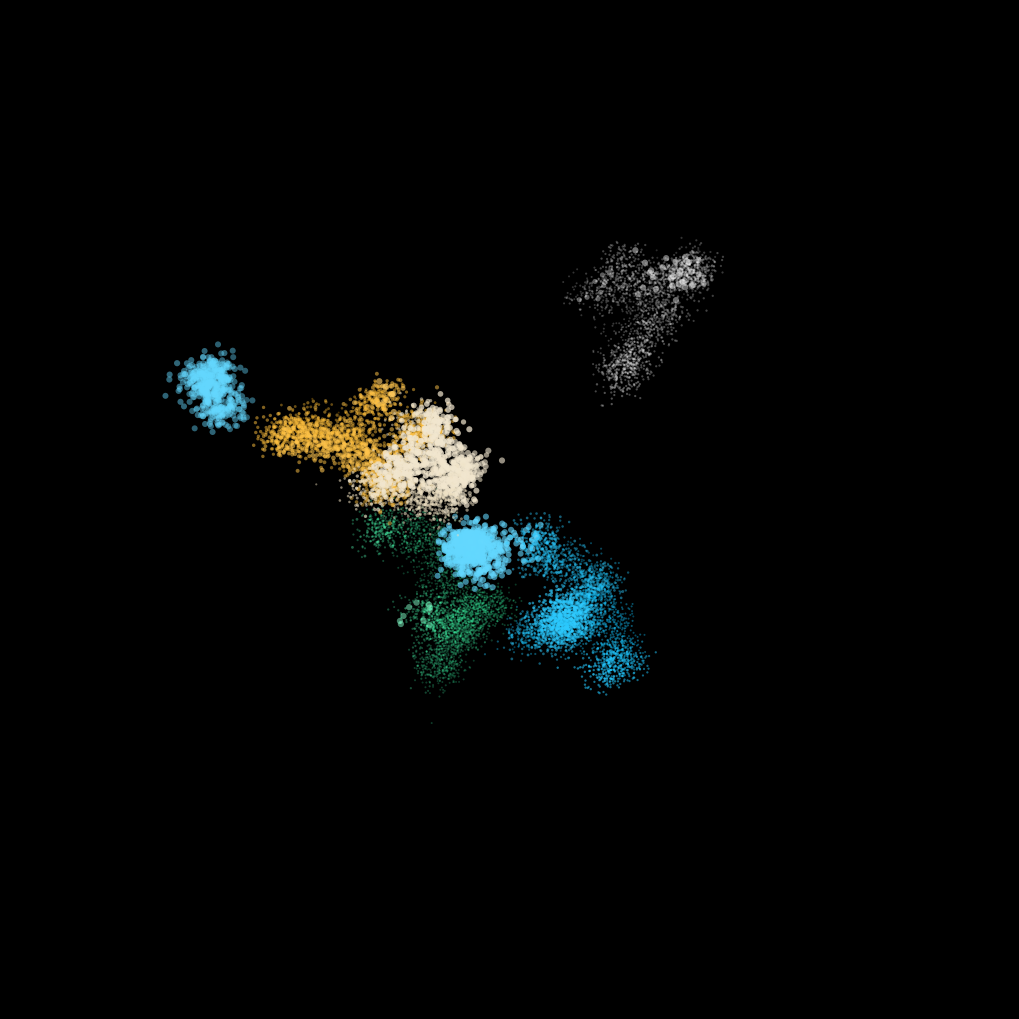

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# --- 4. Animation Settings: 20s Build-up + 30s Rotation ---
plt.close('all')
fig = plt.figure(figsize=(10, 10), facecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')

# 1. Pre-calculate fixed axis limits for a stable view
all_x, all_y, all_z = np.array(aug_x), np.array(aug_y), np.array(aug_z)
pad = 50 
x_lim = (all_x.min() - pad, all_x.max() + pad)
y_lim = (all_y.min() - pad, all_y.max() + pad)
z_lim = (all_z.min() - pad, all_z.max() + pad)

# Initial axis configuration
ax.set_xlim(x_lim)
ax.set_ylim(y_lim)
ax.set_zlim(z_lim)
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

# --- Configuration: 30 seconds at 10 FPS = 300 frames ---
total_points = len(aug_x)
fps = 10
duration = 30
total_frames = fps * duration

def update(frame):
    """Update function for each frame of the animation."""
    # Clear previous scatter plots to free up memory
    for artist in ax.collections:
        artist.remove()

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_zlim(z_lim)
    
    # --- Appearance Logic ---
    # Progress from 0 to 1.0 over the first 20 seconds (200 frames)
    appearance_duration_frames = 20 * fps 
    progress = frame / appearance_duration_frames
    
    # Determine the number of points to display based on progress
    current_point_idx = int(max(1, min(progress, 1.0) * total_points))
    
    ax.scatter(
        aug_x[:current_point_idx], 
        aug_y[:current_point_idx], 
        aug_z[:current_point_idx], 
        s=aug_sizes[:current_point_idx], 
        c=aug_rgba[:current_point_idx], 
        edgecolors='none', 
        antialiased=True
    )
    
    # --- Camera Rotation Logic ---
    # Complete 360-degree rotation over the full 30 seconds
    angle_step = 360 / total_frames
    ax.view_init(elev=25, azim=-45 + (frame * angle_step))
    
    return fig,

# Create the animation object
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=1000/fps)

# --- 5. Export as GIF ---
output_gif = "Walking_20sec_BuildUp.gif"
print(f"Rendering 20s build-up GIF (300 frames)...")

try:
    # Using 'pillow' writer for GIF generation
    ani.save(output_gif, writer='pillow', fps=fps)
    print(f"✅ Success! Animation saved as: {output_gif}")
except Exception as e:
    print(f"❌ Error during rendering: {e}")

plt.show()

画像を保存しました: umap_overlap_mapped.png (重複地点を強調)


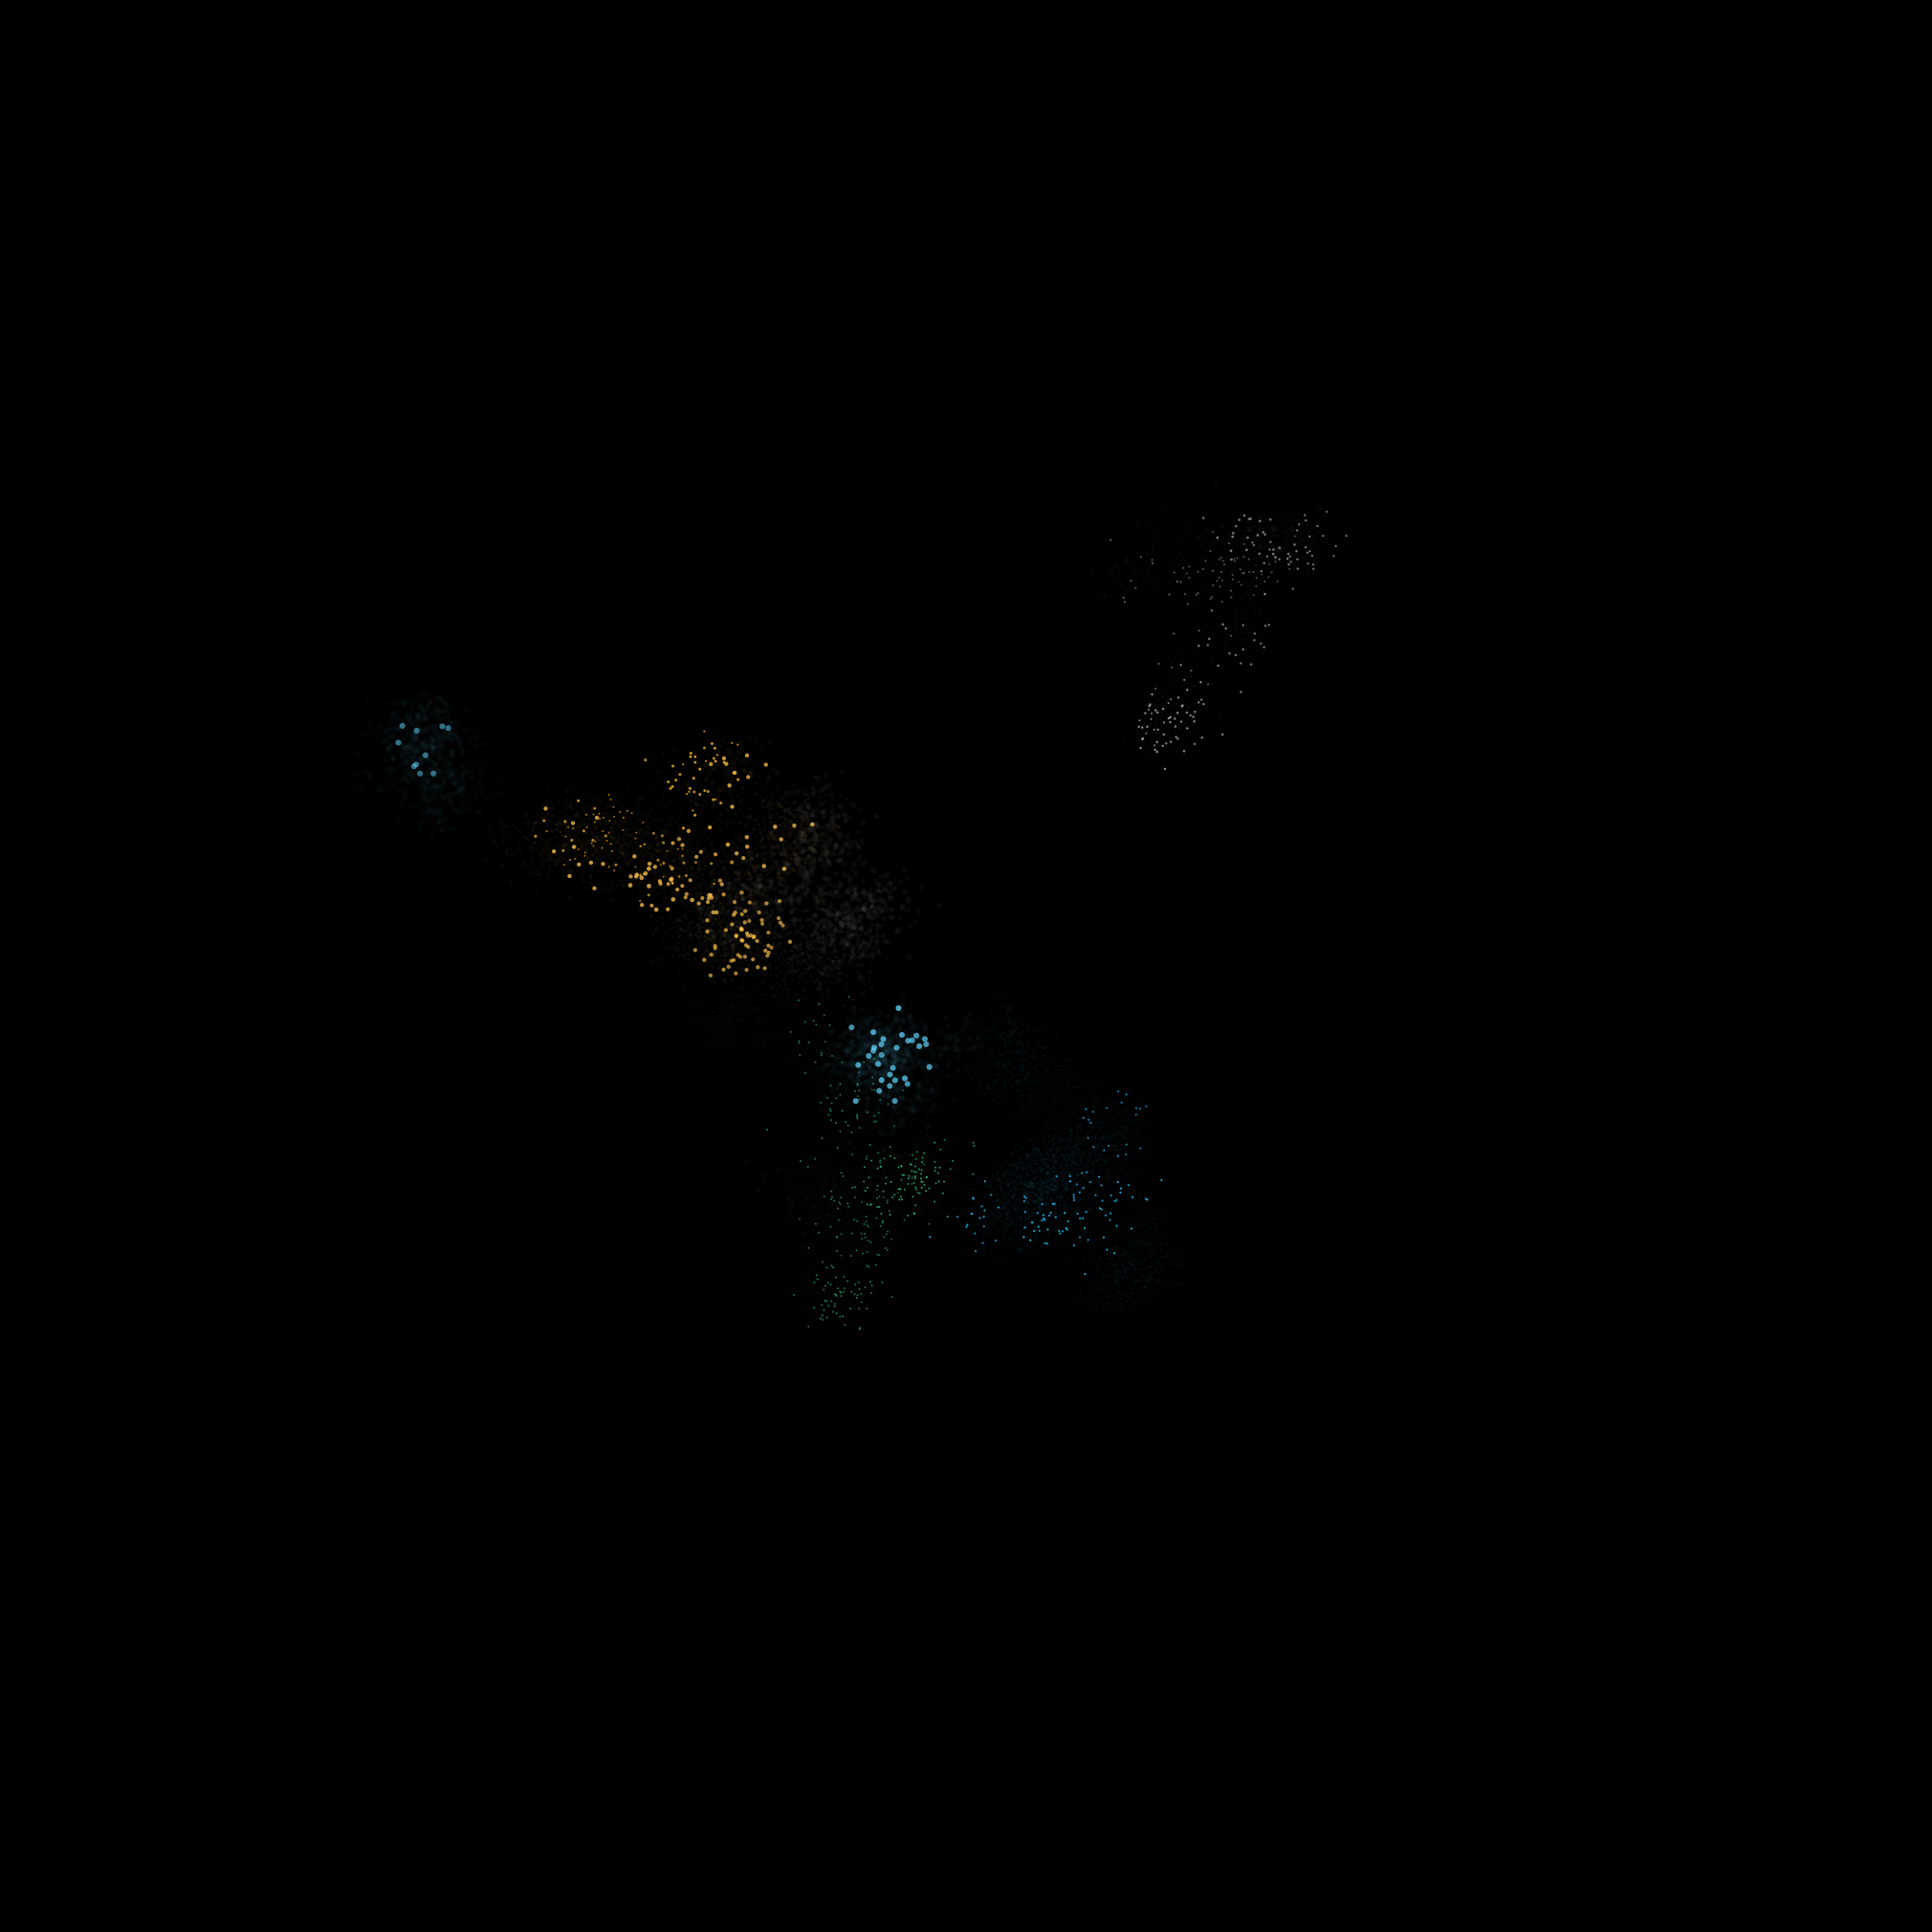

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob

# --- 1. Data Loading ---
# Find and sort all relevant UMAP result CSV files
file_paths = sorted(glob.glob('*_test_umap_result.csv'))
data_list = [pd.read_csv(path) for path in file_paths]
df_combined = pd.concat(data_list, ignore_index=True) if data_list else pd.DataFrame()

# Column names for Geolocation
lat_col, lon_col = 'Lat', 'Lon'

# --- 2. Distance Calculation & Overlap Detection ---
def get_distance(lat1, lon1, lat2, lon2):
    """Calculate the great-circle distance between two points on the Earth (Haversine formula)."""
    R = 6371000 # Earth radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def find_best_match(df_a, df_b):
    """Find the point with the minimum distance between two datasets."""
    min_d = float('inf')
    best_pt = (0, 0)
    # Optimized search using a step of 3 for efficiency
    for i in range(0, len(df_a), 3):
        for j in range(0, len(df_b), 3):
            d = get_distance(df_a.iloc[i][lat_col], df_a.iloc[i][lon_col], 
                             df_b.iloc[j][lat_col], df_b.iloc[j][lon_col])
            if d < min_d:
                min_d = d
                best_pt = (df_a.iloc[i][lat_col], df_a.iloc[i][lon_col])
    return best_pt

# Identify key overlap points (reference points) between sequential routes
# Locations: North (W1-W2), Mid (W2-W3-W4), South (W3-W4)
pt_n = find_best_match(data_list[0], data_list[1].iloc[:len(data_list[1])//2])
pt_m = find_best_match(data_list[1].iloc[len(data_list[1])//2:], data_list[2].iloc[:len(data_list[2])//2])
pt_s = find_best_match(data_list[2].iloc[len(data_list[2])//2:], data_list[3].iloc[:len(data_list[3])//2])

targets = [pt_n, pt_m, pt_s]
radius_m = 35.0 # Radius in meters for defining a "spatial overlap"

# --- 3. Data Augmentation & Visual Mapping Logic ---
augmentation_factor = 10
noise_level = 25 
scale_factor = 50 
min_point_size = 2.0 

# Separate lists for background (low-alpha) and highlighted (high-alpha) points
bg_x, bg_y, bg_z, bg_rgba, bg_sizes = [], [], [], [], []
hi_x, hi_y, hi_z, hi_rgba, hi_sizes = [], [], [], [], []

# Color palette: Blue, Green, Orange, White, Beige
f_colors_hex = ['#00BFFF', '#32FFA6', '#FFAB00', '#FFFFFF']
rgb_palette = [mcolors.hex2color(c) for c in f_colors_hex]
rgb_palette.append((234/255, 216/255, 178/255)) 

for i, file_df in enumerate(data_list):
    indiv_min, indiv_max = file_df['GSR'].min(), file_df['GSR'].max()
    base_rgb = rgb_palette[i % len(rgb_palette)]
    
    # Determine which points fall within the spatial overlap radius
    is_near = pd.Series([False] * len(file_df))
    for pt in targets:
        dist = get_distance(file_df[lat_col], file_df[lon_col], pt[0], pt[1])
        is_near = is_near | (dist <= radius_m)

    for idx, row in file_df.iterrows():
        # Coordinates in UMAP latent space
        bx, by, bz = row['u_x'] * scale_factor, row['u_y'] * scale_factor, row['u_z'] * scale_factor
        
        # Calculate relative GSR intensity for scaling
        rel_gsr = (row['GSR'] - indiv_min) / (indiv_max - indiv_min + 1e-6)
        p_size = min_point_size + (np.power(rel_gsr, 3) * 18.0)
        
        # Color intensity based on GSR
        r = base_rgb[0] + (1.0 - base_rgb[0]) * rel_gsr * 0.4
        g = base_rgb[1] + (1.0 - base_rgb[1]) * rel_gsr * 0.4
        b = base_rgb[2] + (1.0 - base_rgb[2]) * rel_gsr * 0.4
        
        # High opacity for spatial overlaps, near-transparency for background
        if is_near[idx]:
            alpha = 0.9 # Highlighted Overlaps
            target_list_x, target_list_y, target_list_z, target_list_c, target_list_s = hi_x, hi_y, hi_z, hi_rgba, hi_sizes
        else:
            alpha = 0.05 # Background Context (Subtle)
            target_list_x, target_list_y, target_list_z, target_list_c, target_list_s = bg_x, bg_y, bg_z, bg_rgba, bg_sizes

        # Perform data augmentation by adding Gaussian noise
        for _ in range(augmentation_factor):
            target_list_x.append(bx + np.random.randn() * noise_level)
            target_list_y.append(by + np.random.randn() * noise_level)
            target_list_z.append(bz + np.random.randn() * noise_level)
            target_list_c.append([r, g, b, alpha])
            target_list_s.append(p_size)

# --- 4. Plot Execution ---
plt.close('all')
fig = plt.figure(figsize=(20, 20), facecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')

# Render Background points
ax.scatter(bg_x, bg_y, bg_z, s=bg_sizes, c=bg_rgba, edgecolors='none', antialiased=True)
# Render Highlighted points (Physically overlapping locations)
ax.scatter(hi_x, hi_y, hi_z, s=hi_sizes, c=hi_rgba, edgecolors='none', antialiased=True)

ax.set_axis_off()
ax.view_init(elev=25, azim=-45)
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

output_filename = "umap_overlap_mapped.png"
plt.savefig(output_filename, dpi=300, facecolor='black', bbox_inches='tight', pad_inches=0)
print(f"✅ Success! Image saved as: {output_filename} (Overlapping points highlighted)")
plt.show()

C:\Users\taiga\AppData\Local\Temp\ipykernel_61188\678710652.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(np.linspace(0.3, 0.9, len(data_df)))
C:\Users\taiga\AppData\Local\Temp\ipykernel_61188\678710652.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(np.linspace(0.3, 0.9, len(data_df)))


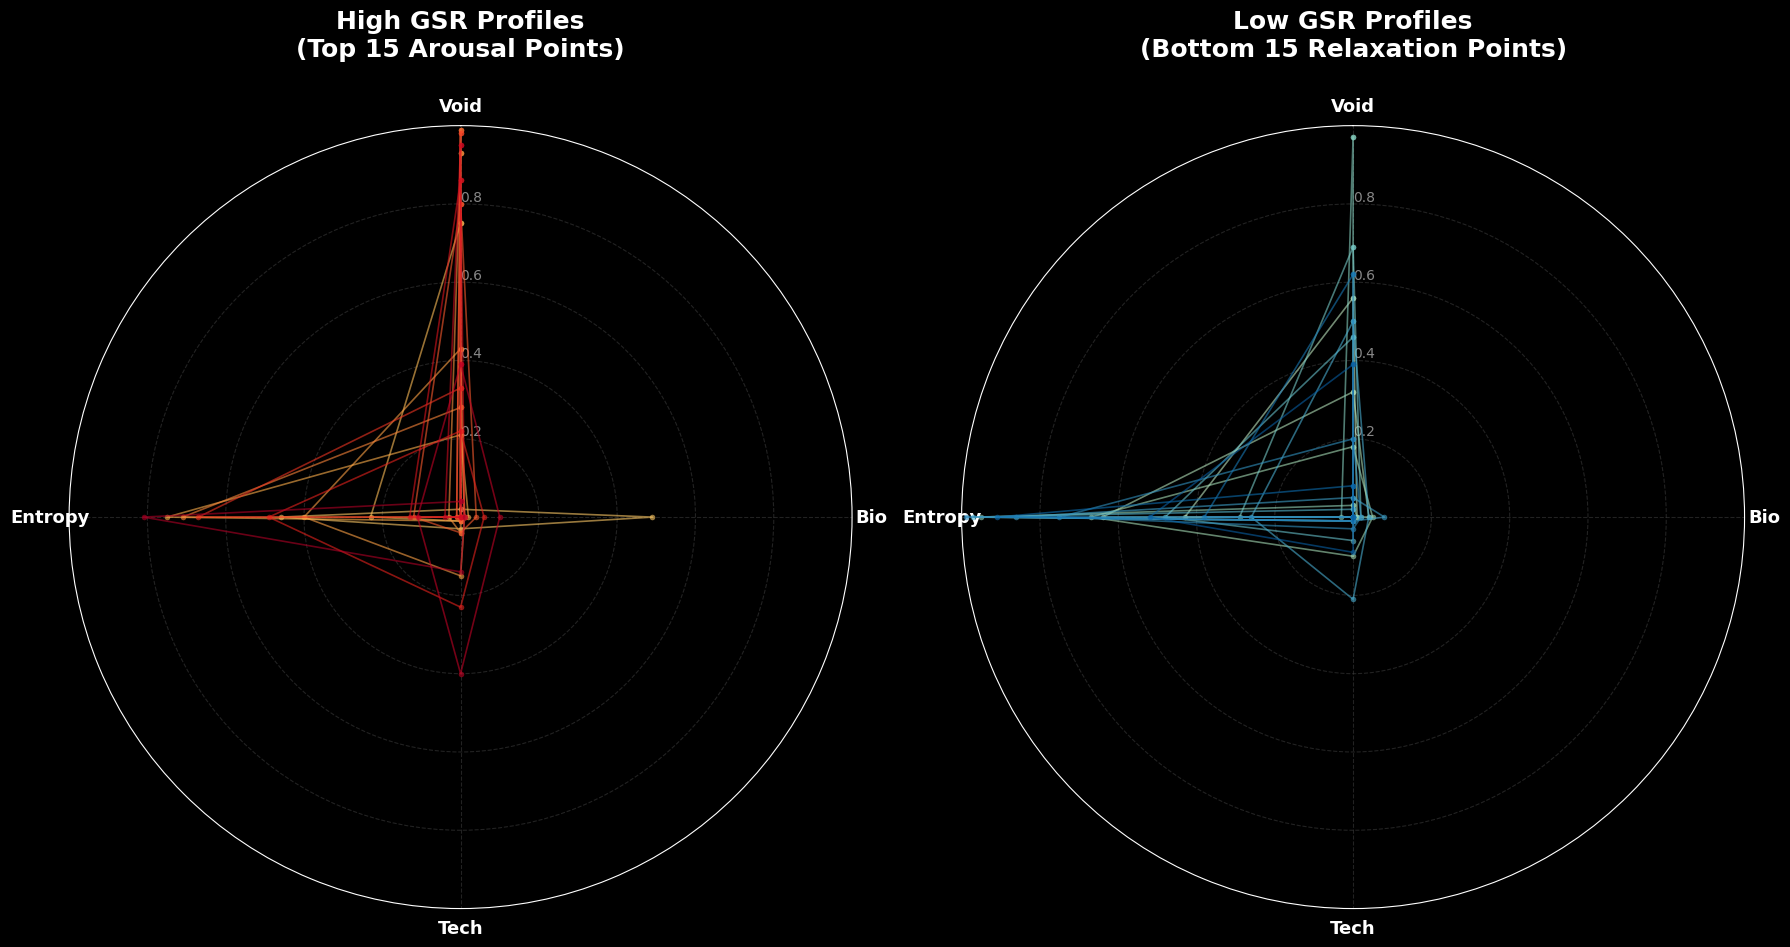

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import matplotlib.cm as cm

# ---------------------------------------------------------
# 1. Data Loading
# ---------------------------------------------------------
file_path = '002_test_umap_result.csv'
df = pd.read_csv(file_path)

# Define the 4 environmental dimensions
categories = ['Void', 'Bio', 'Tech', 'Entropy']
N = len(categories)
# Calculate angles for the radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Close the loop

# ---------------------------------------------------------
# 2. Data Extraction: Extremes of Physiological Arousal
# ---------------------------------------------------------
# Get the top 15 points (Highest GSR) and bottom 15 points (Lowest GSR)
top_15_df = df.nlargest(15, 'GSR')[categories]
bottom_15_df = df.nsmallest(15, 'GSR')[categories]

# ---------------------------------------------------------
# 3. Visualization Setup
# ---------------------------------------------------------
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), subplot_kw=dict(polar=True))

def plot_multicolor_radar_with_markers(ax, data_df, cmap_name, title):
    """Generates a multi-layered radar chart with color gradients and markers."""
    # Generate a color palette based on the chosen colormap
    colors = cm.get_cmap(cmap_name)(np.linspace(0.3, 0.9, len(data_df)))
    
    for i in range(len(data_df)):
        values = data_df.iloc[i].values.flatten().tolist()
        values += values[:1] # Close the loop
        
        # Plot lines with markers
        ax.plot(
            angles, values, color=colors[i], linewidth=1.2, alpha=0.6, 
            marker='o', markersize=4, markeredgewidth=0, label=f'Point {i+1}'
        )
    
    # Aesthetic configuration
    ax.set_theta_offset(pi / 2) # Start from the top
    ax.set_theta_direction(-1) # Clockwise
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, color='white', size=13, weight='bold')
    
    # Grid and Label settings
    ax.set_rlabel_position(0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color="#888888", size=10)
    ax.set_ylim(0, 1.0)
    ax.grid(True, color="#444444", linestyle='--', alpha=0.5)
    ax.set_title(title, size=18, color='white', pad=50, weight='bold')

# Left Plot: High GSR (Warm colors for Arousal)
plot_multicolor_radar_with_markers(
    ax1, top_15_df, 'YlOrRd', 'High GSR Profiles\n(Top 15 Arousal Points)'
)

# Right Plot: Low GSR (Cool colors for Relaxation)
plot_multicolor_radar_with_markers(
    ax2, bottom_15_df, 'GnBu', 'Low GSR Profiles\n(Bottom 15 Relaxation Points)'
)

plt.tight_layout()

# ---------------------------------------------------------
# 4. Export
# ---------------------------------------------------------
output_path = 'GSR_Multicolor_Radar_Markers.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='#000000')
print(f"✅ Success! Radar charts saved to: {output_path}")
plt.show()